# Billboard Hot 100 Data
## Notebook Summary

This notebook processes weekly Billboard Hot 100 chart data into a song-level lifecycle dataset. Weekly chart appearances are aggregated into individual song records, lifecycle metrics are engineered, and exploratory analyses are performed to examine long-term changes in chart dynamics.

### Inputs

* `hot100.csv`

### Outputs

* `billboard_song_lifecycle.csv`
* `top40_billboard_dataset.csv`

### Key Contributions

* Construct song-level lifecycle metrics from weekly chart records.
* Measure chart longevity, virality, and persistence over time.
* Generate Billboard trend analyses and final poster visualizations.

## Data Source

Billboard Hot 100 weekly chart data was obtained from the Kaggle dataset:

https://www.kaggle.com/datasets/ludmin/billboard/data?select=hot100.csv

The dataset contains weekly Billboard Hot 100 chart positions and metadata. This project uses records from 2005 onward to construct song-level lifecycle metrics and downstream audio analyses.

## 0)   Setup

- Load the Billboard Hot 100 weekly chart dataset.
- Filter records to the study period beginning in 2005.
- Prepare chart data for lifecycle feature engineering and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import time
import re
from difflib import SequenceMatcher

In [2]:
# =========================
# Load Full Billboard Hot 100 data
# =========================

df_billboard = pd.read_csv("../data/raw/hot100.csv")

# Convert chart dates into datetime
df_billboard["Date"] = pd.to_datetime(
    df_billboard["Date"],
    errors="coerce"
)

# Filter to 2005
# 2005 allows for radio era + streaming + TikTok
df_billboard = df_billboard[
    df_billboard["Date"].dt.year >= 2005
].copy()

latest_date = df_billboard["Date"].max()

print("Oldest date:", df_billboard["Date"].min())
print("Newest date:", latest_date)
print("Weekly chart rows:", df_billboard.shape[0])


Oldest date: 2005-01-05 00:00:00
Newest date: 2026-05-20 00:00:00
Weekly chart rows: 111500


## 1)  Preprocessing - Feature Engineering

- Convert weekly chart records into a song-level dataset.
- Engineer lifecycle metrics describing chart performance over time.
- Construct the foundational Billboard dataset used throughout the project.

### Collapse (one row per song)

In [ ]:
# =========================
# Collapse weekly chart rows into song-level lifecycle dataframe
# =========================

df = df_billboard.copy()

# Collapse and retain data
song_life = (
    df.sort_values("Date")
      .groupby(["Song", "Artist"], as_index=False)
      .agg(
          first_chart_date=("Date", "min"),
          last_chart_date=("Date", "max"),
          entry_rank=("Rank", "first"),
          peak_rank=("Rank", "min"),
          total_weeks=("Weeks in Charts", "max"),
          top10_weeks=("Rank", lambda x: (x <= 10).sum()),
          top40_weeks=("Rank", lambda x: (x <= 40).sum()),
          avg_rank=("Rank", "mean"),
          image_url=("Image URL", "first")
      )
)

# Find first date when each song hit its peak rank
peak_dates = (
    df.sort_values("Date")
      .loc[
          df.sort_values("Date")
            .groupby(["Song", "Artist"])["Rank"]
            .idxmin(),
          ["Song", "Artist", "Date"]
      ]
      .rename(columns={"Date": "peak_date"})
)

# Merge
song_life = song_life.merge(
    peak_dates,
    on=["Song", "Artist"],
    how="left"
)

### Lifecycle timing metrics

In [ ]:
# =========================
# Add lifecycle timing metrics
# =========================

# Total lifecycle length on chart
song_life["lifespan_weeks"] = song_life["total_weeks"]

# Weeks from first chart appearance to peak rank
song_life["time_to_peak"] = (
    (song_life["peak_date"] - song_life["first_chart_date"]).dt.days / 7
)

# Entry year
song_life["entry_year"] = song_life["first_chart_date"].dt.year

# Era label
song_life["era"] = np.where(
    song_life["entry_year"] < 2016,
    "Pre TikTok",
    "Post TikTok"
)

# Higher value = better peak
song_life["peak_success"] = 101 - song_life["peak_rank"]

# Higher value = better average chart position
song_life["avg_success"] = 101 - song_life["avg_rank"]

# Weeks since last chart appearance
song_life["weeks_since_last_chart"] = (
    (latest_date - song_life["last_chart_date"]).dt.days / 7
)

# Flag songs whose chart run may still be incomplete near dataset endpoint
song_life["potentially_incomplete"] = (
    song_life["weeks_since_last_chart"] < 4
)

## 2) Review & Export (billboard_song_lifecycle.csv)

Review:

- Perform quality assurance checks on engineered lifecycle metrics.
- Identify potentially incomplete songs still active on the charts.
- Export the completed Billboard lifecycle dataset for downstream analysis.

Export:
billboard_song_lifecycle.csv

`billboard_song_lifecycle.csv` is a song-level dataset with one row per unique song/artist.

- includes first/last chart dates, peak date, entry/peak ranks
- lifecycle metrics: total weeks, top 10/40 weeks, avg rank, lifespan, time-to-peak
- derived features: era label, peak success, average success, and incomplete-run flag

In [ ]:
# =========================
# Quality check
# =========================

print("Song-level rows:", song_life.shape[0])

song_life[
    [
        "peak_rank",
        "peak_success",
        "total_weeks",
        "top10_weeks",
        "top40_weeks",
        "avg_rank",
        "time_to_peak",
        "entry_year"
    ]
].describe()

Song-level rows: 10505


,peak_rank,peak_success,total_weeks,top10_weeks,top40_weeks,avg_rank,time_to_peak,entry_year
count,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000
mean,50.337363,50.662637,10.834745,1.061399,4.245597,65.043306,6.055307,2016.312613
std,29.269174,29.269174,11.691683,4.156856,9.235043,22.089007,23.873402,6.229256
min,1.000000,1.000000,1.000000,0.000000,0.000000,3.750000,0.000000,2005.000000
25%,25.000000,26.000000,1.000000,0.000000,0.000000,51.157895,0.000000,2011.000000
50%,52.000000,49.000000,6.000000,0.000000,0.000000,68.000000,0.000000,2017.000000
75%,75.000000,76.000000,20.000000,0.000000,2.000000,82.600000,8.000000,2022.000000
max,100.000000,100.000000,112.000000,80.000000,94.000000,100.000000,681.000000,2026.000000


In [ ]:
song_life_all = song_life.copy()

song_life_completed = song_life[
    song_life["potentially_incomplete"] == False
].copy()

print("All songs:", song_life_all.shape)
print("Completed-only songs:", song_life_completed.shape)

All songs: (10505, 17)
Completed-only songs: (10363, 17)


In [ ]:
# Preview final Billboard lifecycle dataframe
song_life.head()

,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,image_url,peak_date,lifespan_weeks,time_to_peak,entry_year,era,peak_success,avg_success,weeks_since_last_chart,potentially_incomplete
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,https://charts-static.billboard.com/img/2019/1...,2021-06-02,4,0.0,2021,Post TikTok,82,46.750000,256.0,False
1,"""1, 2 Many""",Luke Combs & Brooks & Dunn,2019-09-25,2019-09-25,97,97,1,0,0,97.000000,https://charts-static.billboard.com/img/2015/0...,2019-09-25,1,0.0,2019,Post TikTok,4,4.000000,347.0,False
2,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,https://charts-static.billboard.com/img/2004/0...,2005-01-05,39,0.0,2005,Pre TikTok,99,81.551724,1087.0,False
3,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,https://charts-static.billboard.com/img/2005/1...,2009-05-20,20,15.0,2009,Pre TikTok,67,53.200000,883.0,False
4,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,https://charts-static.billboard.com/img/2019/1...,2019-10-16,30,0.0,2019,Post TikTok,97,85.066667,315.0,False


In [ ]:
# Save to CSV
song_life.to_csv(
    "../data/intermediate/billboard_song_lifecycle.csv",
    index=False
)

print("Saved billboard_song_lifecycle.csv to intermediate data folder.")

Saved billboard_song_lifecycle.csv


In [ ]:
# Create Top-40 Billboard dataset for Apple Music matching
top40 = song_life[song_life["peak_rank"] <= 40].copy()

top40.to_csv("../data/intermediate/top40_billboard_dataset.csv", index=False)

print("Saved top40_billboard_dataset.csv")
print("Top-40 dataset shape:", top40.shape)

## 3) Exploratory Analysis

- Explore long-term trends in Billboard chart behavior.
- Examine song longevity, chart turnover, and peak-performance patterns.
- Identify trends that informed the final poster analyses.

### Song counts by year

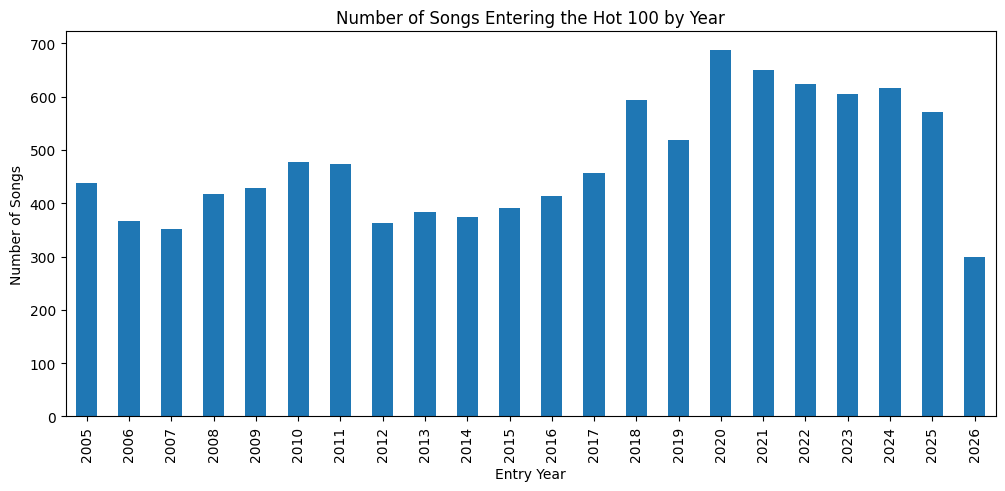

In [ ]:
# ================================
# SONG COUNTS BY YEAR
# ================================

song_life_all.groupby("entry_year").size().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Number of Songs Entering the Hot 100 by Year")
plt.xlabel("Entry Year")
plt.ylabel("Number of Songs")
plt.show()

### Incomplete songs by year

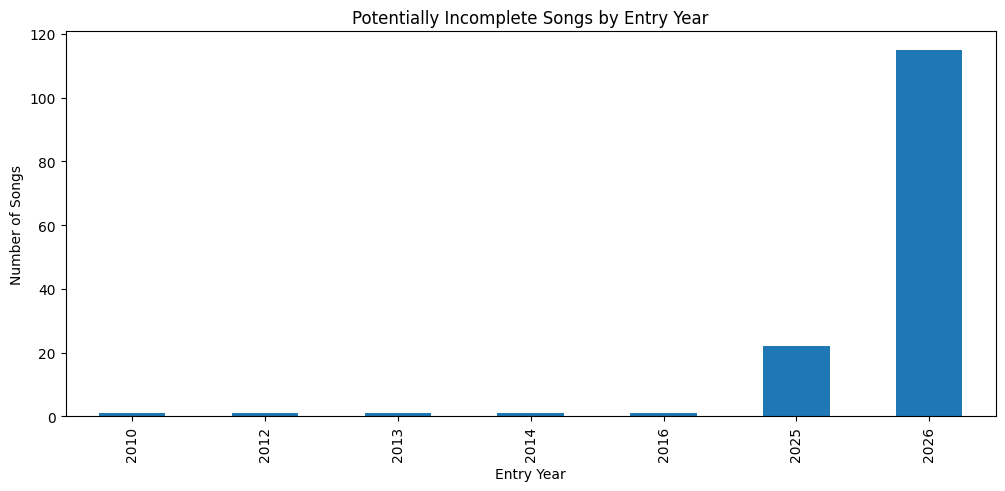

In [ ]:
# ================================
# INCOMPLETE SONGS CHECK
# ================================

excluded_by_year = (
    song_life[song_life["potentially_incomplete"]]
    .groupby("entry_year")
    .size()
)

excluded_by_year.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Potentially Incomplete Songs by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Number of Songs")
plt.show()

### Lifespan (all + completed)

#### Median Lifespan

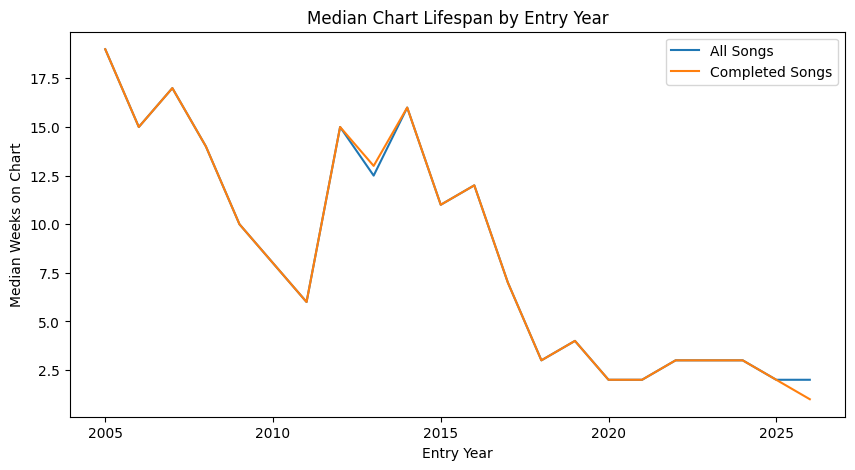

In [ ]:
# ================================
# MEDIAN LIFESPAN
# ALL VS COMPLETED COMPARISON
# ================================

median_comparison = pd.DataFrame({
    "All Songs": median_all,
    "Completed Songs": median_completed
})

median_comparison.plot(figsize=(10, 5))

plt.title("Median Chart Lifespan by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

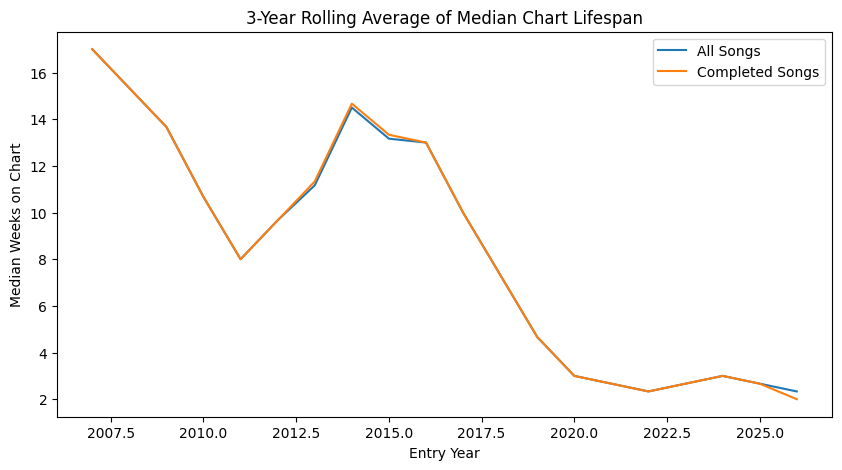

In [ ]:
# ================================
# SMOOTHED TREND
# ================================

median_comparison.rolling(3).mean().plot(figsize=(10, 5))

plt.title("3-Year Rolling Average of Median Chart Lifespan")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

#### Average Lifespan

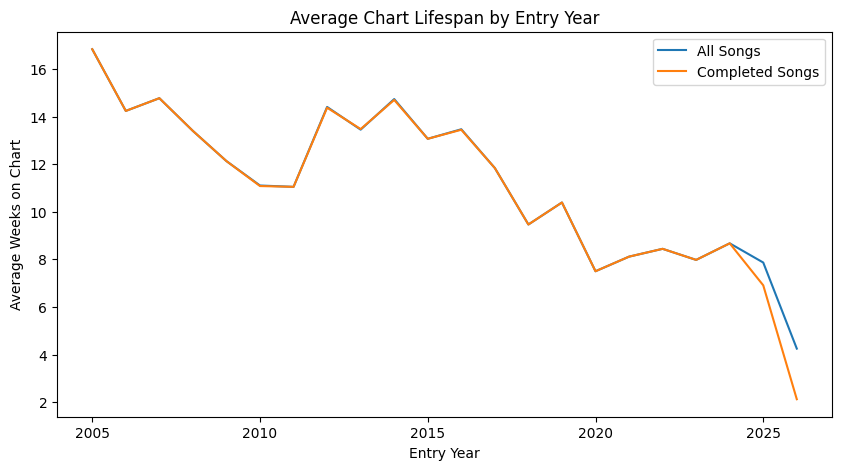

In [ ]:
# ================================
# MEAN LIFESPAN
# ================================

mean_all = (
    song_life_all
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

mean_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

mean_comparison = pd.DataFrame({
    "All Songs": mean_all,
    "Completed Songs": mean_completed
})

mean_comparison.plot(figsize=(10, 5))

plt.title("Average Chart Lifespan by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Weeks on Chart")
plt.show()

### Time to Peak

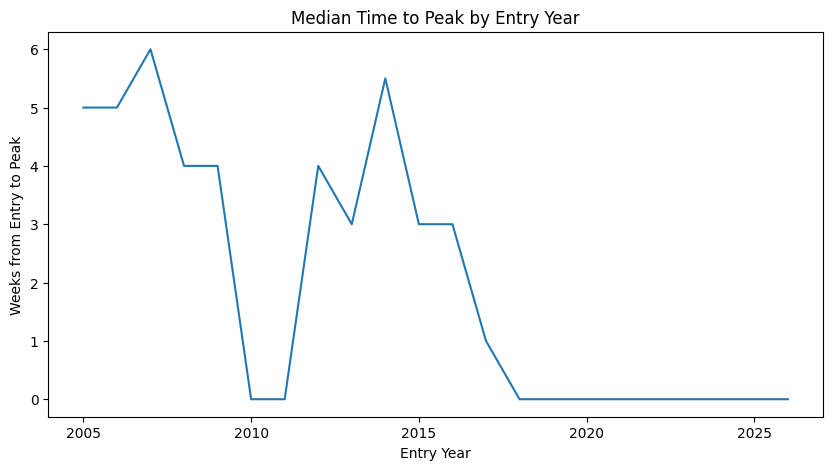

In [ ]:
# ================================
# TIME TO PEAK
# ================================

time_to_peak_by_year = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

time_to_peak_by_year.plot(figsize=(10, 5))

plt.title("Median Time to Peak by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Weeks from Entry to Peak")
plt.show()

### Average weeks in Top 10

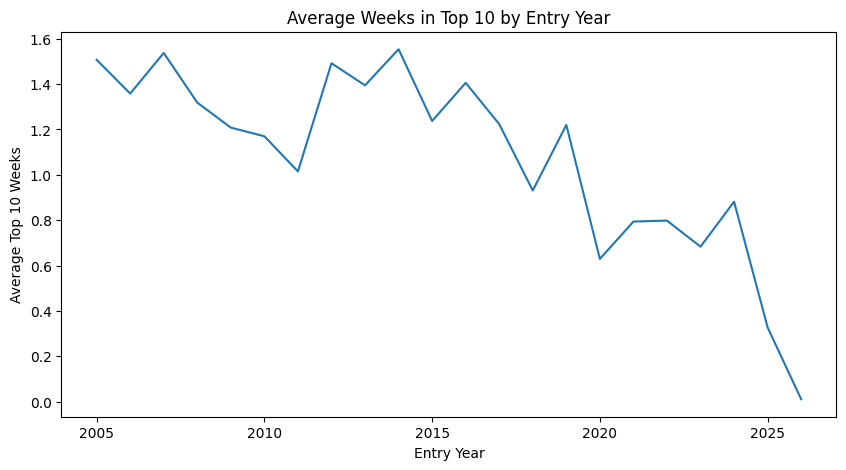

In [ ]:
# ================================
# TOP 10 PERSISTENCE
# ================================

# (uses mean because median gave '0' across the board since 
# less than half actually made Top 10)
top10_by_year = (
    song_life_completed
    .groupby("entry_year")["top10_weeks"]
    .mean()
)

top10_by_year.plot(figsize=(10, 5))

plt.title("Average Weeks in Top 10 by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Top 10 Weeks")
plt.show()

### Average weeks in Top 40

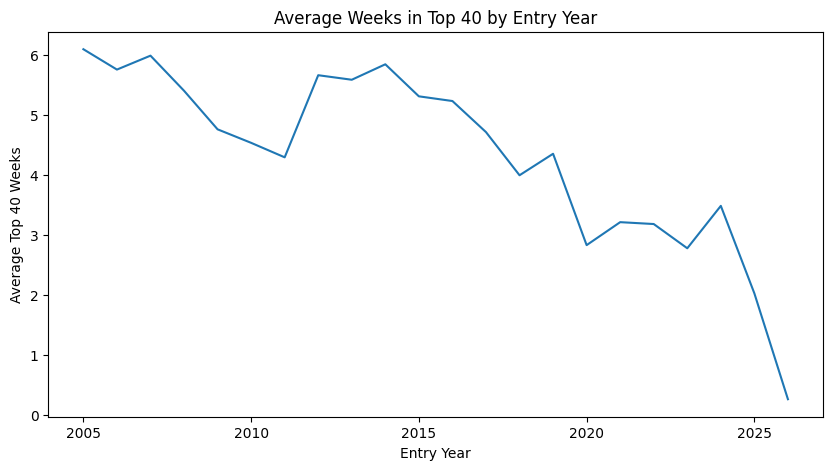

In [ ]:
# ================================
# TOP 40 PERSISTENCE
# ================================

# (uses mean because median gave '0' across the board since 
# less than half actually made Top 40)
top40_by_year = (
    song_life_completed
    .groupby("entry_year")["top40_weeks"]
    .mean()
)

top40_by_year.plot(figsize=(10, 5))

plt.title("Average Weeks in Top 40 by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Top 40 Weeks")
plt.show()

### Median lifespan by entry year (Top 10 & Top 40)

(<Axes: xlabel='entry_year'>, <Axes: xlabel='entry_year'>)

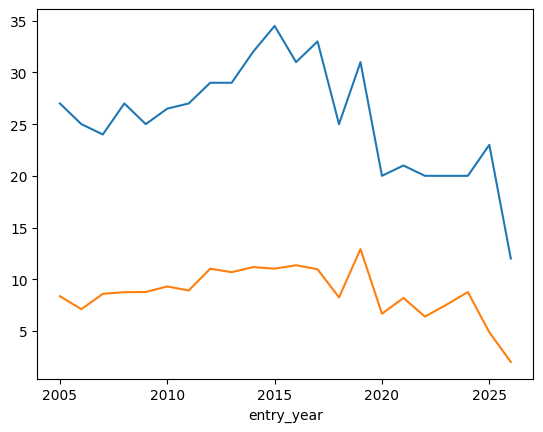

In [ ]:
# Isolating Top10 and Top40 hits
top10_hits = song_life_completed[
    song_life_completed["peak_rank"] <= 10
]

top40_hits = song_life_completed[
    song_life_completed["peak_rank"] <= 40
]

top10_hits.groupby("entry_year")["lifespan_weeks"].median().plot(), top10_hits.groupby("entry_year")["top10_weeks"].mean().plot()


### % Reaching Top 10

/var/folders/bk/yngmbh1j5xdf2sk9yktp2cbr0000gn/T/ipykernel_19886/293373601.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["peak_rank"] <= 10).mean())


<Axes: xlabel='entry_year'>

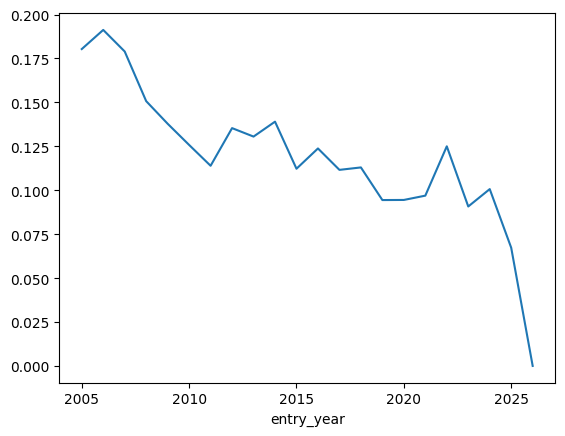

In [ ]:
# Percent of hits that reach top 10
percent_top10 = (
    song_life_completed
    .groupby("entry_year")
    .apply(lambda x: (x["peak_rank"] <= 10).mean())
)
percent_top10.plot()

## 4) Final Poster Billboard Chart Visualizations

- Generate the Billboard figures used in the final poster.
- Highlight trends in longevity, virality, and chart turnover.
- Summarize the major changes observed in chart dynamics over time.

### Longevity: Median Chart Lifespan by Year

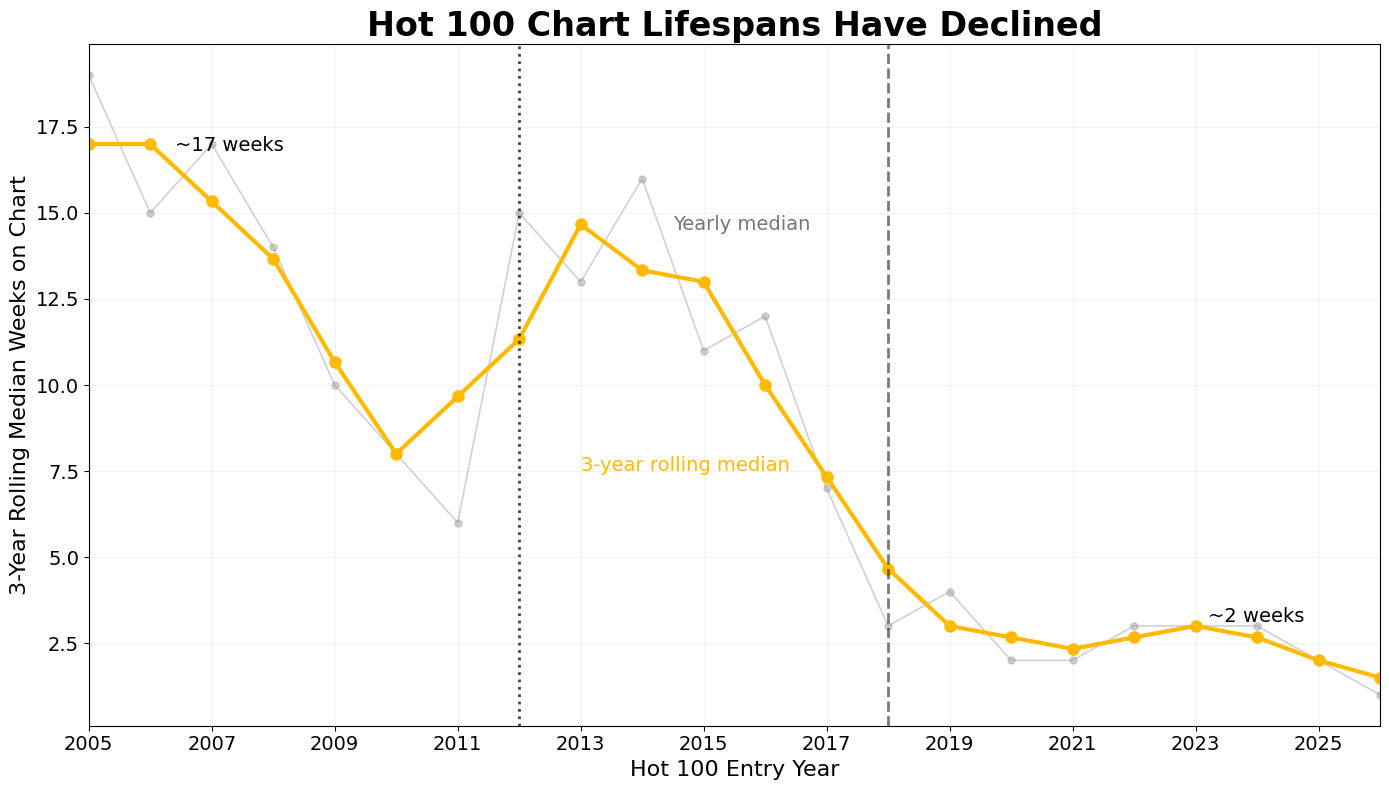

In [ ]:
# ============================================================
# Billboard Lifespan Trend (Final Poster Version)
# ============================================================

median_lifespan_all = (
    song_life
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

median_lifespan_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

# ------------------------------------------------------------
# 3-year rolling median
# ------------------------------------------------------------
median_lifespan_completed_roll = (
    median_lifespan_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1
    )
    .mean()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# Raw yearly median in background
ax.plot(
    median_lifespan_completed.index,
    median_lifespan_completed.values,
    marker="o",
    markersize=5,
    linewidth=1.2,
    color="#999999",
    alpha=0.45,
    label="Yearly median"
)

# Rolling median as main trend
ax.plot(
    median_lifespan_completed_roll.index,
    median_lifespan_completed_roll.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#ffba00",
    label="3-year rolling median"
)
# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Endpoint annotations
# ------------------------------------------------------------
ax.text(
    2006.4,
    16.8,
    "~17 weeks",
    fontsize=14
)

ax.text(
    2023.2,
    3.1,
    "~2 weeks",
    fontsize=14
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hot 100 Chart Lifespans Have Declined",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "3-Year Rolling Median Weeks on Chart",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2026)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
ax.text(
    2013,
    7.5,
    "3-year rolling median",
    color="#ffba00",
    fontsize=14
)

ax.text(
    2014.5,
    14.5,
    "Yearly median",
    color="#777777",
    fontsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_lifespan_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Virality: Median Time-to-Peak by Year

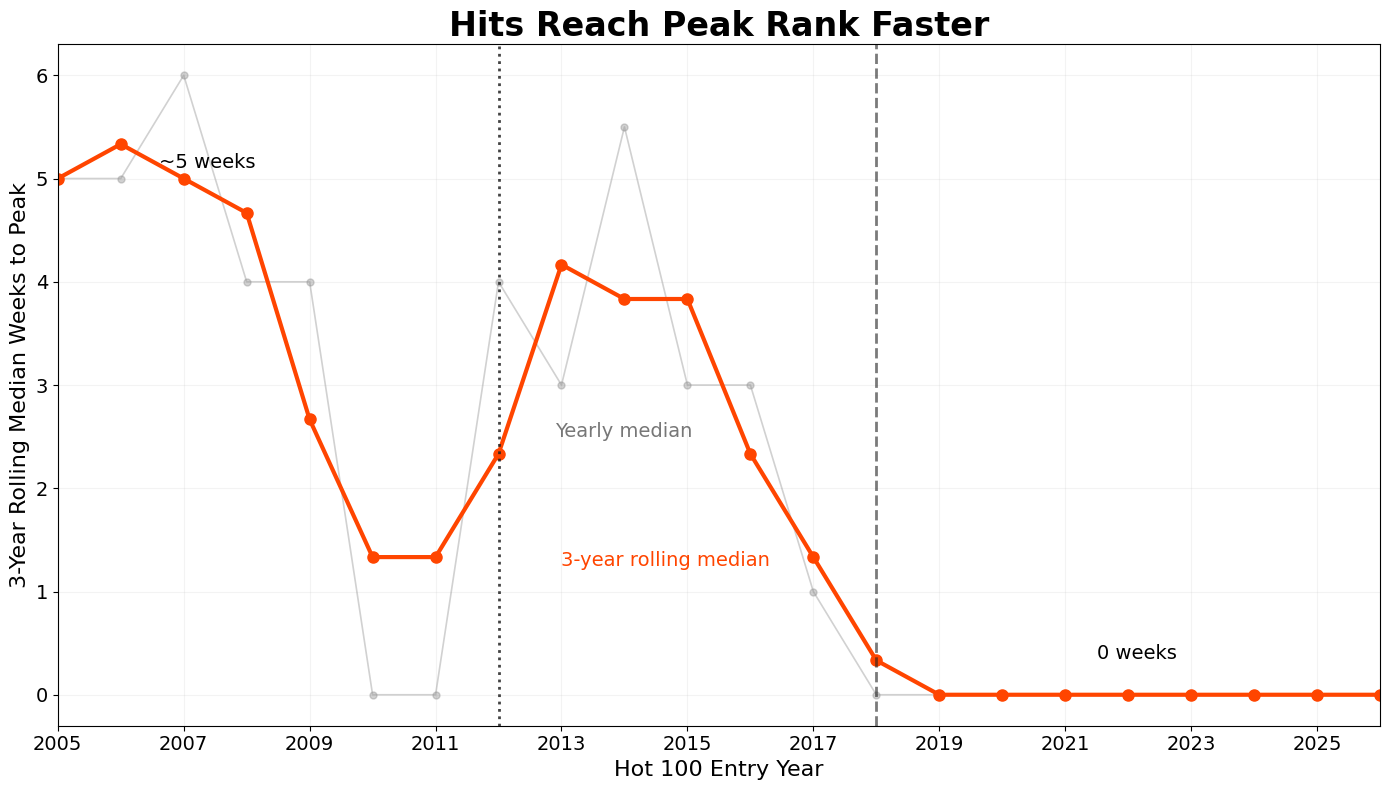

In [ ]:
# ============================================================
# Billboard Time-to-Peak Trend (Final Poster Version)
# ============================================================

# ------------------------------------------------------------
# Yearly median time to peak for completed songs only
# ------------------------------------------------------------
median_time_to_peak_completed = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

# ------------------------------------------------------------
# 3-year rolling median
# ------------------------------------------------------------
median_time_to_peak_completed_roll = (
    median_time_to_peak_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1
    )
    .mean()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

# Raw yearly median in background
ax.plot(
    median_time_to_peak_completed.index,
    median_time_to_peak_completed.values,
    marker="o",
    markersize=5,
    linewidth=1.2,
    color="#999999",
    alpha=0.45,
    label="Yearly median"
)

# Rolling median as main trend
ax.plot(
    median_time_to_peak_completed_roll.index,
    median_time_to_peak_completed_roll.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#ff4500",
    label="3-year rolling median"
)

# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Endpoint annotations
# ------------------------------------------------------------
ax.text(
    2006.6,
    5.1,
    "~5 weeks",
    fontsize=14
)

ax.text(
    2021.5,
    0.35,
    "0 weeks",
    fontsize=14
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hits Reach Peak Rank Faster",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "3-Year Rolling Median Weeks to Peak",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2026)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Direct labels instead of legend
# ------------------------------------------------------------
ax.text(
    2013,
    1.25,
    "3-year rolling median",
    color="#ff4500",
    fontsize=14
)

ax.text(
    2012.9,
    2.5,
    "Yearly median",
    color="#777777",
    fontsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_time_to_peak_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Chart Turnover: # of New Songs Entering Charts by Year

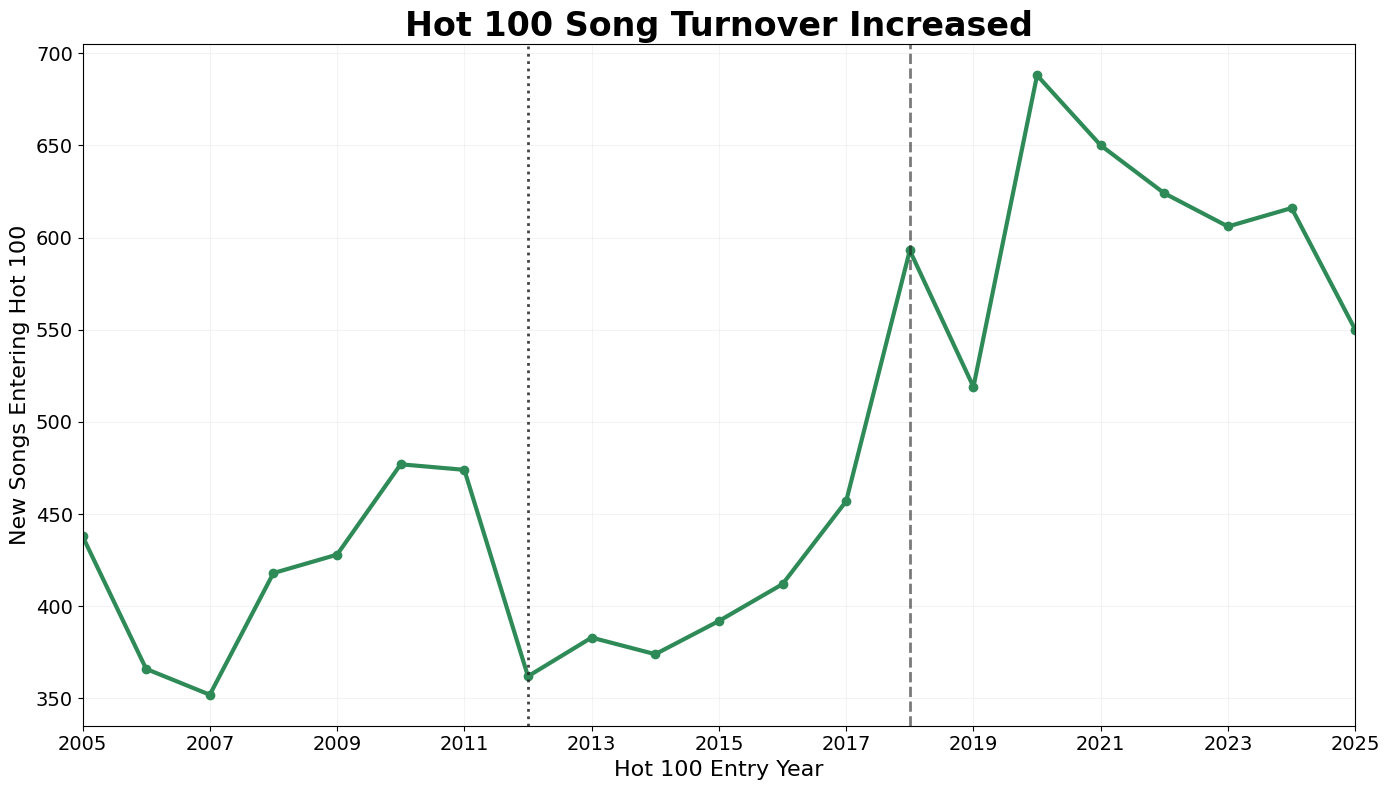

In [ ]:
# ============================================================
# Hot 100 Song Turnover Trend (Final Poster Version)
# ============================================================

# ------------------------------------------------------------
# Count unique songs entering each year
# ------------------------------------------------------------
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
)

# Remove incomplete 2026
songs_per_year = songs_per_year.loc[
    songs_per_year.index <= 2025
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(
    songs_per_year.index,
    songs_per_year.values,
    marker="o",
    linewidth=3,
    color="#2E8B57"
)
# ------------------------------------------------------------
# Era milestone lines
# ------------------------------------------------------------
ax.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.0,
    color="#222222",
    alpha=0.85
)

ax.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.0,
    color="#222222",
    alpha=0.60
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------
ax.set_title(
    "Hot 100 Song Turnover Increased",
    fontsize=24,
    fontweight="bold"
)

ax.set_xlabel(
    "Hot 100 Entry Year",
    fontsize=16
)

ax.set_ylabel(
    "New Songs Entering Hot 100",
    fontsize=16
)

ax.set_xticks(range(2005, 2026, 2))
ax.set_xlim(2005, 2025)

ax.tick_params(
    axis="both",
    labelsize=14
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    True,
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "hot100_song_turnover_trend.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Summary Statistics

In [ ]:
# -----------------------------
# Make yearly song counts
# -----------------------------
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
    .reset_index(name="songs_per_year")
)

songs_per_year["era"] = np.where(
    songs_per_year["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Average number of unique Hot 100 entries per year in each era
songs_per_year_summary = (
    songs_per_year
    .groupby("era")["songs_per_year"]
    .mean()
)

# -----------------------------
# 2. Make chart dynamics summary
# -----------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Median Lifespan (weeks)",
        "Median Time to Peak (weeks)",
        "% Reaching Top 10",
        "Avg. Songs Entering / Year"
    ],
    "Pre TikTok": [
        era_summary.loc["Pre TikTok", "median_lifespan"],
        era_summary.loc["Pre TikTok", "median_time_to_peak"],
        era_summary.loc["Pre TikTok", "percent_top10"],
        songs_per_year_summary.loc["Pre TikTok"]
    ],
    "Post TikTok": [
        era_summary.loc["Post TikTok", "median_lifespan"],
        era_summary.loc["Post TikTok", "median_time_to_peak"],
        era_summary.loc["Post TikTok", "percent_top10"],
        songs_per_year_summary.loc["Post TikTok"]
    ],
    "p-value": [
        "<0.001",
        "<0.001",
        "<0.001",
        "0.003"
    ]
})

# -----------------------------
# 3. Calculate percent change
# -----------------------------
summary_table["% Change"] = (
    (
        (summary_table["Post TikTok"] - summary_table["Pre TikTok"])
        / summary_table["Pre TikTok"]
    ) * 100
).round(1)

# Add + sign for increases
summary_table["% Change"] = summary_table["% Change"].apply(
    lambda x: f"+{x}%" if x > 0 else f"{x}%"
)

# -----------------------------
# 4. Round values for readability
# -----------------------------
summary_table["Pre TikTok"] = summary_table["Pre TikTok"].round(1)
summary_table["Post TikTok"] = summary_table["Post TikTok"].round(1)

summary_table = summary_table[
    [
        "Metric",
        "Pre TikTok",
        "Post TikTok",
        "% Change",
        "p-value"
    ]
]
display(summary_table)

# Optional export
# summary_table.to_csv("chart_dynamics_summary_table.csv", index=False)

,Metric,Pre TikTok,Post TikTok,% Change,p-value
0,Median Lifespan (weeks),13.0,2.0,-84.6%,<0.001
1,Median Time to Peak (weeks),3.0,0.0,-100.0%,<0.001
2,% Reaching Top 10,14.0,9.5,-32.1%,<0.001
3,Avg. Songs Entering / Year,410.2,558.9,+36.2%,0.003


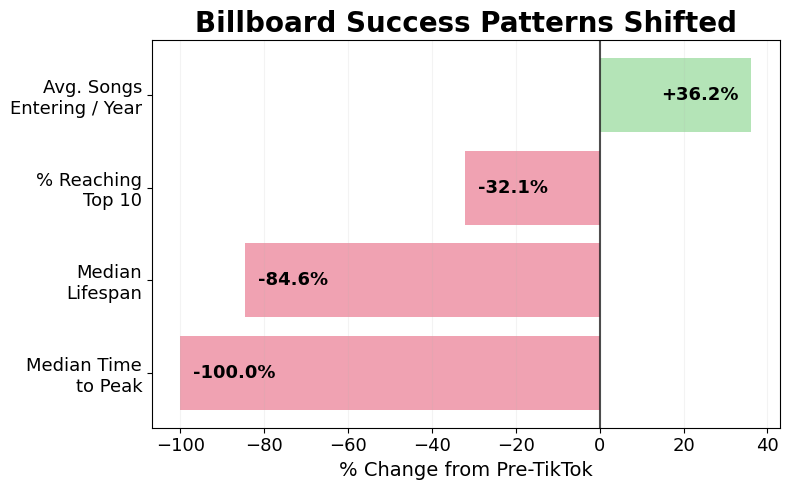

In [ ]:
# ============================================================
# Billboard Success Patterns Shifted
# ============================================================

billboard_change = pd.DataFrame({
    "Metric": [
        "Avg. Songs\nEntering / Year",
        "% Reaching\nTop 10",
        "Median\nLifespan",
        "Median Time\nto Peak"
    ],
    "% Change": [
        36.2,
        -32.1,
        -84.6,
        -100.0
    ]
})

billboard_change = billboard_change.sort_values("% Change")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [
    "#ef98aa" if x < 0 else "#ace1af"
    for x in billboard_change["% Change"]
]

bars = ax.barh(
    billboard_change["Metric"],
    billboard_change["% Change"],
    color=bar_colors,
    alpha=0.90
)

# ------------------------------------------------------------
# Zero line
# ------------------------------------------------------------
ax.axvline(
    x=0,
    color="#222222",
    linewidth=1.5,
    alpha=0.80
)

# ------------------------------------------------------------
# Labels
# Match style of audio feature chart
# ------------------------------------------------------------
for i, value in enumerate(billboard_change["% Change"]):

    if value > 0:
        ax.text(
            value - 3,
            i,
            f"{value:+.1f}%",
            va="center",
            ha="right",
            fontsize=13,
            fontweight="bold"
        )

    else:
        ax.text(
            value + 3,
            i,
            f"{value:+.1f}%",
            va="center",
            ha="left",
            fontsize=13,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Title and labels
# ------------------------------------------------------------
ax.set_title(
    "Billboard Success Patterns Shifted",
    fontsize=20,
    fontweight="bold"
)

ax.set_xlabel(
    "% Change from Pre-TikTok",
    fontsize=14
)

ax.tick_params(
    axis="both",
    labelsize=13
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    axis="x",
    alpha=0.15
)

fig.tight_layout()

# ------------------------------------------------------------
# Export
# ------------------------------------------------------------
filename = "billboard_metric_changes.png"

fig.savefig(
    filename,
    dpi=1200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()